# Direct normal-tree edge-closed regions

For each normal node-time cut $t$, this notebook keeps every edge whose parent is older than $t$. It reports a region only when its connected older-edge component has one contiguous genomic support and no other older component overlaps that support.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=r"Pandas requires version .* of 'numexpr'")
    import pandas as pd
import tskit
from IPython.display import display


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start).expanduser().resolve()
    fallback = Path("/Users/pratik/Documents/work/aim3/simpliied")
    for candidate in (start, *start.parents, fallback):
        if (candidate / "arg/new_rl/normal_ts_edge_closed_regions.py").is_file():
            return candidate
    raise RuntimeError("Could not locate the workspace root")


WORKSPACE_ROOT = find_workspace_root()
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

from arg.new_rl.normal_ts_edge_closed_regions import (
    benchmark_normal_ts_edge_closed_regions,
    normal_edge_components_at_cut,
    scan_normal_ts_edge_closed_regions,
)

INPUT_PATHS = {
    "25 kb": WORKSPACE_ROOT / "arg/validation/output/tsinfer/l25kb_dated.trees",
    "1 Mb": WORKSPACE_ROOT / "arg/validation/output/tsinfer/l1mb_dated.trees",
}
for input_path in INPUT_PATHS.values():
    if not input_path.is_file():
        raise FileNotFoundError(input_path)

## Scan every normal parent-time cut

The 25 kb result retains its full per-cut diagnostic catalog. The 1 Mb result streams summaries and discovered regions only.

In [2]:
normal_edge_reference_results = {
    label: scan_normal_ts_edge_closed_regions(
        input_path,
        retain_per_cut_catalog=(label == "25 kb"),
        algorithm="reference",
    )
    for label, input_path in INPUT_PATHS.items()
}
normal_edge_scan_results = {
    label: scan_normal_ts_edge_closed_regions(
        input_path,
        retain_per_cut_catalog=(label == "25 kb"),
        algorithm="incremental",
    )
    for label, input_path in INPUT_PATHS.items()
}

normal_edge_closed_regions = {
    label: result.regions
    for label, result in normal_edge_scan_results.items()
}

def semantic_region_signature(region):
    return tuple(
        sorted(
            (key, repr(value))
            for key, value in region.items()
            if key not in {"root_node_id", "component_id"}
        )
    )

normal_edge_parity = {}
for label, incremental in normal_edge_scan_results.items():
    reference = normal_edge_reference_results[label]
    assert reference.per_cut_summary == tuple(
        {key: value for key, value in summary.items() if key in {
            "cut_index", "cut_time", "older_edges", "frontier_edges",
            "components", "edge_closed_components",
        }}
        for summary in incremental.per_cut_summary
    )
    assert sorted(map(semantic_region_signature, reference.regions)) == sorted(
        map(semantic_region_signature, incremental.regions)
    )
    normal_edge_parity[label] = True

{
    label: {
        "normal_cuts": len(result.per_cut_summary),
        "raw_edge_closed_components": result.raw_closed_component_count,
        "deduplicated_regions": len(result.regions),
        "incremental_scan_seconds": result.scan_seconds,
        "reference_scan_seconds": normal_edge_reference_results[label].scan_seconds,
        "reference_edge_visits": normal_edge_reference_results[label].diagnostics["older_edge_visits"],
        "incremental_edge_visits": result.diagnostics["older_edge_visits"],
    }
    for label, result in normal_edge_scan_results.items()
}

{'25 kb': {'normal_cuts': 13,
  'raw_edge_closed_components': 9,
  'deduplicated_regions': 2,
  'incremental_scan_seconds': 0.0013807500363327563,
  'reference_scan_seconds': 0.0020923750125803053,
  'reference_edge_visits': 206,
  'incremental_edge_visits': 30},
 '1 Mb': {'normal_cuts': 473,
  'raw_edge_closed_components': 1335,
  'deduplicated_regions': 32,
  'incremental_scan_seconds': 0.10763437498826534,
  'reference_scan_seconds': 1.1746744160191156,
  'reference_edge_visits': 453635,
  'incremental_edge_visits': 1703}}

In [3]:
def region_summary_dataframe(regions):
    return pd.DataFrame(
        [
            {
                "region_id": region["region_id"],
                "left": region["left"],
                "right": region["right"],
                "span": region["span"],
                "first_cut_index": region["first_normal_cut_index"],
                "first_cut_time": region["first_normal_cut_time"],
                "last_cut_index": region["last_normal_cut_index"],
                "last_cut_time": region["last_normal_cut_time"],
                "valid_cut_count": region["valid_normal_cut_count"],
                "older_edges": region["older_edge_count"],
                "frontier_edges": region["frontier_edge_count"],
                "nodes": region["node_count"],
            }
            for region in regions
        ]
    )

normal_edge_closed_regions_df = {
    label: region_summary_dataframe(regions)
    for label, regions in normal_edge_closed_regions.items()
}
for label, summary in normal_edge_closed_regions_df.items():
    print(label)
    display(summary)

25 kb


,region_id,left,right,span,first_cut_index,first_cut_time,last_cut_index,last_cut_time,valid_cut_count,older_edges,frontier_edges,nodes
0,normal-edge-region-0000,386.0,23963.0,23577.0,0,0.000000,7,10163.963287,8,30,14,20
1,normal-edge-region-0001,3440.0,9543.0,6103.0,11,58442.228572,11,58442.228572,1,3,3,4


1 Mb


,region_id,left,right,span,first_cut_index,first_cut_time,last_cut_index,last_cut_time,valid_cut_count,older_edges,frontier_edges,nodes
0,normal-edge-region-0000,892.0,999859.0,998967.0,0,0.000000,233,10285.121534,234,1703,603,483
1,normal-edge-region-0001,892.0,6564.0,5672.0,319,17224.072004,385,31145.602809,67,5,5,5
2,normal-edge-region-0002,936205.0,940685.0,4480.0,333,18892.417792,401,35874.845849,69,2,2,3
3,normal-edge-region-0003,324207.0,325397.0,1190.0,345,22279.468169,438,45195.004810,94,2,2,3
4,normal-edge-region-0004,331893.0,351270.0,19377.0,356,24404.679603,356,24404.679603,1,11,11,10
5,normal-edge-region-0005,349767.0,351270.0,1503.0,357,24404.679603,406,36593.165382,50,5,5,5
6,normal-edge-region-0006,134074.0,143404.0,9330.0,365,25614.496711,394,33750.282879,30,7,7,7
7,normal-edge-region-0007,110932.0,119529.0,8597.0,366,26087.940643,378,28944.704216,13,2,2,3
8,normal-edge-region-0008,899943.0,900438.0,495.0,371,26979.858754,454,51705.598615,84,2,2,3
9,normal-edge-region-0009,153474.0,157894.0,4420.0,375,27791.243993,471,74789.489570,97,3,3,4


In [4]:
normal_edge_benchmarks = {
    label: benchmark_normal_ts_edge_closed_regions(input_path)
    for label, input_path in INPUT_PATHS.items()
}
normal_edge_benchmark_df = pd.DataFrame(
    [
        {
            "fixture": label,
            "reference_seconds": benchmark.reference_seconds,
            "incremental_seconds": benchmark.incremental_seconds,
            "speedup": benchmark.speedup,
            "reference_peak_mb": benchmark.reference_peak_bytes / 2**20,
            "incremental_peak_mb": benchmark.incremental_peak_bytes / 2**20,
            "reference_edge_visits": benchmark.reference_diagnostics["older_edge_visits"],
            "incremental_edge_visits": benchmark.incremental_diagnostics["older_edge_visits"],
            "edge_overlap_pairs": benchmark.incremental_diagnostics.get("edge_overlap_pairs"),
        }
        for label, benchmark in normal_edge_benchmarks.items()
    ]
)
display(normal_edge_benchmark_df)

,fixture,reference_seconds,incremental_seconds,speedup,reference_peak_mb,incremental_peak_mb,reference_edge_visits,incremental_edge_visits,edge_overlap_pairs
0,25 kb,0.009918,0.007802,1.271237,0.036100,0.042274,206,30,282
1,1 Mb,14.845512,1.119672,13.258804,24.188436,23.469719,453635,1703,17874


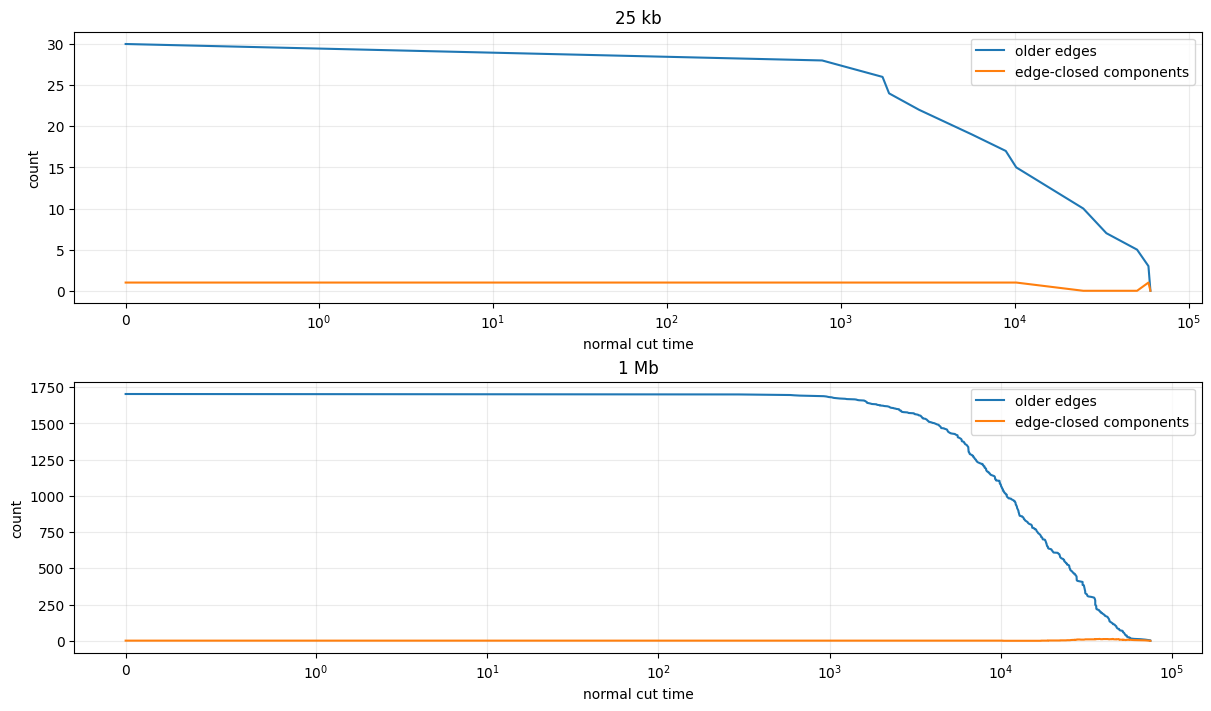

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False, constrained_layout=True)
for axis, (label, result) in zip(axes, normal_edge_scan_results.items()):
    summary = pd.DataFrame(result.per_cut_summary)
    axis.plot(summary["cut_time"], summary["older_edges"], label="older edges")
    axis.plot(summary["cut_time"], summary["edge_closed_components"], label="edge-closed components")
    axis.set_xscale("symlog", linthresh=1.0)
    axis.set_title(label)
    axis.set_xlabel("normal cut time")
    axis.set_ylabel("count")
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()

## Inspect one discovered region

Each horizontal line is an older edge at the region's first valid normal cut. The vertical lines mark the directly discovered genomic boundaries.

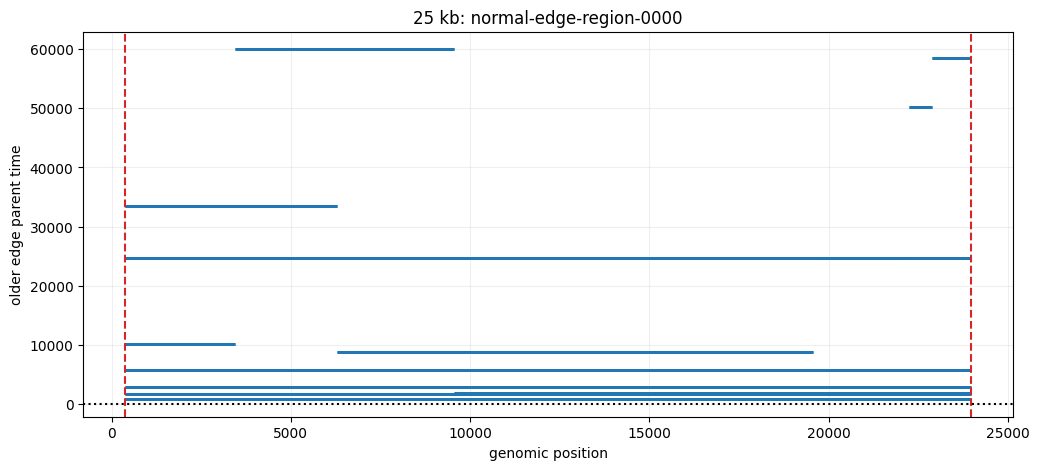

{'cut_index': 0,
 'cut_time': 0.0,
 'root_node_id': 8,
 'region_key': (386.0, 23963.0),
 'intervals': ((386.0, 23963.0),),
 'left': 386.0,
 'right': 23963.0,
 'span': 23577.0,
 'material_length': 23577.0,
 'contiguous': True,
 'proper_subregion': True,
 'older_edge_ids': (0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29),
 'older_edge_count': 30,
 'node_ids': (0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19),
 'node_count': 20,
 'frontier_edge_ids': (0, 1, 2, 3, 4, 5, 6, 8, 11, 13, 14, 15, 20, 27),
 'frontier_edge_count': 14,
 'frontier_anchor_node_ids': (0, 1, 2, 3, 4, 5, 6, 7),
 'assigned_edges_inside': True,
 'outside_older_edge_overlap': False,
 'normal_edge_closed': True,
 'rejection_reasons': (),
 'separation_edge_ids': (),
 'separation_parent_time': 0.0,
 'component_id': 'normal-cut-0-component-0000'}

In [6]:
SELECTED_FIXTURE = "25 kb"
SELECTED_REGION_INDEX = 0

selected_input = tskit.load(str(INPUT_PATHS[SELECTED_FIXTURE]))
selected_region = normal_edge_closed_regions[SELECTED_FIXTURE][SELECTED_REGION_INDEX]
selected_cut = normal_edge_components_at_cut(
    selected_input,
    selected_region["first_normal_cut_time"],
    cut_index=selected_region["first_normal_cut_index"],
)
selected_component = next(
    component
    for component in selected_cut["components"]
    if (component["left"], component["right"]) == (
        selected_region["left"],
        selected_region["right"],
    )
)

edge_table = selected_input.tables.edges
node_time = np.asarray(selected_input.nodes_time)
fig, axis = plt.subplots(figsize=(12, 5))
for edge_id in selected_component["older_edge_ids"]:
    parent = int(edge_table.parent[edge_id])
    axis.hlines(
        node_time[parent],
        edge_table.left[edge_id],
        edge_table.right[edge_id],
        color="tab:blue",
        linewidth=2,
    )
axis.axvline(selected_region["left"], color="tab:red", linestyle="--")
axis.axvline(selected_region["right"], color="tab:red", linestyle="--")
axis.axhline(selected_region["first_normal_cut_time"], color="black", linestyle=":")
axis.set_xlabel("genomic position")
axis.set_ylabel("older edge parent time")
axis.set_title(f"{SELECTED_FIXTURE}: {selected_region['region_id']}")
axis.grid(alpha=0.2)
plt.show()

selected_component

In [7]:
assert len(normal_edge_closed_regions["25 kb"]) == 2
assert len(normal_edge_closed_regions["1 Mb"]) == 32
assert all(normal_edge_parity.values())
assert normal_edge_benchmarks["1 Mb"].speedup >= 5.0
for regions in normal_edge_closed_regions.values():
    for region in regions:
        assert region["normal_edge_closed"]
        assert region["contiguous"]
        assert region["proper_subregion"]
        assert region["frontier_edge_count"] > 0
        assert not region["outside_older_edge_overlap"]
"Direct normal-tree edge-closure checks passed."

'Direct normal-tree edge-closure checks passed.'

## Stage 2 — Exact local-refinement witnesses

For each Stage-1 interval $R=[L,R)$, this stage looks for one event cut whose complete older suffix is an isolated component with support exactly equal to $R$. The chosen witness minimizes internal suffix events, then frontier nodes, then prefers the oldest cut. The younger prefix, genomic exterior, and recorded frontier remain fixed for local refinement.

In [ ]:
import time

from arg.new_rl.exact_closed_cones import (
    assert_synthetic_endpoints_are_normal_breakpoints,
    benchmark_exact_region_witnesses,
)
from arg.new_rl.synthetic_full_arg import build_synthetic_full_arg
from arg.new_rl.trace import build_fast_trace_from_full_arg

exact_witness_pipelines = {}
for label, input_path in INPUT_PATHS.items():
    normal_ts = tskit.load(str(input_path))

    conversion_started = time.perf_counter()
    conversion = build_synthetic_full_arg(
        normal_ts,
        split_rule="balanced",
        ensure_unique_event_times=True,
    )
    conversion_seconds = time.perf_counter() - conversion_started
    synthetic_arg = conversion.tree_sequence
    assert_synthetic_endpoints_are_normal_breakpoints(normal_ts, synthetic_arg)

    trace_started = time.perf_counter()
    trace = build_fast_trace_from_full_arg(
        synthetic_arg, require_unique_event_times=True
    )
    trace_seconds = time.perf_counter() - trace_started
    assert trace.num_steps <= 1 or np.all(np.diff(trace.event_time) > 0.0)

    benchmark = benchmark_exact_region_witnesses(
        trace, normal_edge_closed_regions[label]
    )
    exact_witness_pipelines[label] = {
        "normal_ts": normal_ts,
        "conversion": conversion,
        "synthetic_arg": synthetic_arg,
        "trace": trace,
        "conversion_seconds": conversion_seconds,
        "trace_seconds": trace_seconds,
        "benchmark": benchmark,
        "result": benchmark.incremental_result,
    }

exact_region_witness_results = {
    label: pipeline["result"]
    for label, pipeline in exact_witness_pipelines.items()
}
{
    label: {
        "candidate_regions": len(result.regions),
        "valid_witnesses": len(result.valid_witnesses),
        "incremental_seconds": result.scan_seconds,
    }
    for label, result in exact_region_witness_results.items()
}

In [ ]:
def exact_witness_audit_dataframe(result):
    rows = []
    for region in result.regions:
        rejection_reasons = (
            ()
            if region["status"] == "valid"
            else tuple(
                reason
                for reason, count in region["rejection_diagnostics"].items()
                if count
            )
        )
        rows.append(
            {
                "region_id": region["region_id"],
                "left": region["left"],
                "right": region["right"],
                "span": region["span"],
                "normal_first_cut_time": region["first_normal_cut_time"],
                "normal_last_cut_time": region["last_normal_cut_time"],
                "status": region["status"],
                "witness_cut_step": region["witness_cut_step"],
                "witness_cut_time": region["witness_cut_time"],
                "internal_events": region["witness_internal_event_count"],
                "frontier_nodes": region["witness_frontier_node_count"],
                "rejection_reasons": rejection_reasons,
            }
        )
    return pd.DataFrame(rows)

exact_region_witness_audit_df = {
    label: exact_witness_audit_dataframe(result)
    for label, result in exact_region_witness_results.items()
}
valid_exact_region_witnesses_df = {
    label: frame.loc[frame["status"] == "valid"].reset_index(drop=True)
    for label, frame in exact_region_witness_audit_df.items()
}
for label, frame in exact_region_witness_audit_df.items():
    print(label)
    display(frame)

In [ ]:
exact_witness_benchmark_df = pd.DataFrame(
    [
        {
            "fixture": label,
            "conversion_seconds": pipeline["conversion_seconds"],
            "trace_seconds": pipeline["trace_seconds"],
            "reference_scan_seconds": pipeline["benchmark"].reference_seconds,
            "incremental_scan_seconds": pipeline["benchmark"].incremental_seconds,
            "speedup": pipeline["benchmark"].speedup,
            "event_insertions": pipeline["result"].diagnostics["event_insertions"],
            "edge_insertions": pipeline["result"].diagnostics["edge_insertions"],
            "incremental_suffix_rebuilds": pipeline["result"].diagnostics["suffix_rebuilds"],
            "reference_suffix_rebuilds": pipeline["benchmark"].reference_result.diagnostics["suffix_rebuilds"],
        }
        for label, pipeline in exact_witness_pipelines.items()
    ]
)
display(exact_witness_benchmark_df)

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
for axis, (label, result) in zip(axes, exact_region_witness_results.items()):
    witnesses = list(result.valid_witnesses)
    event_counts = np.asarray(
        [region["witness_internal_event_count"] for region in witnesses]
    )
    normalizer = plt.Normalize(
        vmin=event_counts.min(), vmax=max(event_counts.max(), event_counts.min() + 1)
    )
    color_map = plt.get_cmap("viridis")
    for region in witnesses:
        axis.hlines(
            region["witness_cut_time"],
            region["left"],
            region["right"],
            color=color_map(normalizer(region["witness_internal_event_count"])),
            linewidth=4,
            alpha=0.85,
        )
    axis.set_xlim(0.0, float(exact_witness_pipelines[label]["trace"].sequence_length))
    axis.set_yscale("symlog", linthresh=1.0)
    axis.set_xlabel("genomic position")
    axis.set_ylabel("selected exact cut time")
    axis.set_title(f"{label}: exact local-refinement witnesses")
    axis.grid(alpha=0.25)
plt.show()

In [ ]:
expected_valid_witness_counts = {"25 kb": 1, "1 Mb": 25}
certificate_fields = (
    "boundary_step", "boundary_time", "lower_frontier_anchor_node_ids",
    "frontier_segments", "suffix_event_indices", "edge_ids", "node_ids",
    "terminal_lineage_ids", "event_count", "separation_event_index",
)
for label, expected_count in expected_valid_witness_counts.items():
    pipeline = exact_witness_pipelines[label]
    result = pipeline["result"]
    reference = pipeline["benchmark"].reference_result
    trace = pipeline["trace"]
    assert len(result.valid_witnesses) == expected_count
    assert result.diagnostics["event_insertions"] == trace.num_steps
    assert result.diagnostics["edge_insertions"] == trace.revealed_edge_ids.size
    assert result.diagnostics["suffix_rebuilds"] == 0
    for region, reference_region in zip(result.regions, reference.regions):
        assert region["status"] == reference_region["status"]
        if region["status"] != "valid":
            continue
        witness = region["witness"]
        reference_witness = reference_region["witness"]
        assert witness["intervals"] == ((region["left"], region["right"]),)
        assert witness["closure_verified"] and witness["exact"]
        assert witness["lower_frontier_anchor_node_ids"]
        assert not witness["outside_overlap_edge_ids"]
        for field in certificate_fields:
            assert witness[field] == reference_witness[field]
"Exact local-refinement witness checks passed."